# Part 2: Flow Matching Parameterization

In [1]:
from src.model import JiM
from src.train import train_n_steps
from src.denoiser import Denoiser
from src.dataloader import get_dataloader

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

In [2]:
AVAILABLE_DATASETS = ("swiss_roll", "gaussians", "circles")
DIMS = (2, 8, 32)
PRED_LOSS = (("x", "x"), ("x", "v"), ("v", "x"), ("v", "v"))

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path("res/part2")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_STEPS = 25000          # adjust to hit ~25k steps given your dataset size
STEPS = 50
BATCH = 1024
N_GEN = 2048           # samples to generate for visualization

### Helpers

In [10]:
def model_tag(dataset, D, pred, loss):
    return f"{dataset}_D{D}_{pred}pred_{loss}loss"


def train_one_config(dataset, D, pred_type, loss_type, device, n_steps=25_000):
    dataloader = get_dataloader(name=dataset, dim=D, batch_size=1024)
    model = JiM(hidden_dim=256, D=D).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    losses = train_n_steps(model, dataloader, opt, device, n_steps, pred_type, loss_type)
    tag = model_tag(dataset, D, pred_type, loss_type)
    torch.save(model.state_dict(), MODEL_DIR / f"{tag}.pt")
    np.save(MODEL_DIR / f"{tag}_losses.npy", np.asarray(losses, dtype=np.float32))
    return model


def generate_samples(model, D, pred_type, device, n=N_GEN):
    denoiser = Denoiser(model, steps=STEPS, D=D)
    return denoiser.generate(n, pred_type, device).cpu().numpy()


def get_ground_truth(dataset, D, n=N_GEN):
    loader = get_dataloader(name=dataset, dim=D, batch_size=n)
    return next(iter(loader))[:n].cpu().numpy()


def project_to_2d(samples, dataset, D):
    if D == 2:
        return samples
    loader = get_dataloader(name=dataset, dim=D, batch_size=1)
    return loader.dataset.to_2d(torch.from_numpy(samples)).numpy()


def density_coverage(gen, real, k=5):
    """Density & Coverage (Naeem et al. 2020) — manifold-aware quality metrics.

    Builds a 'manifold ball' around each real point: radius r_i = distance from
    real_i to its k-th nearest neighbour within the real set (k=5 by default).

    Density = (1 / (k * |gen|)) * sum_{j} sum_{i} 1{ ||gen_j - real_i|| < r_i }
        For every generated point, count how many real-balls contain it; average
        over generated points and divide by k. High Density = generated samples
        land in densely-populated regions of the real manifold (≈ fidelity, the
        'on-manifold' score). Can slightly exceed 1.0 when gen points cluster
        inside heavily-overlapping real-balls.

    Coverage = (1 / |real|) * sum_{i} 1{ min_j ||gen_j - real_i|| < r_i }
        Fraction of real points whose ball contains at least one generated point.
        High Coverage = the real manifold is well covered by generated samples
        (≈ diversity, catches mode collapse). Strictly in [0, 1].

    Both metrics are higher = better, and they're more robust to outliers than
    the older Precision/Recall pair (Kynkäänniemi et al. 2019)."""
    gen, real = np.asarray(gen, dtype=np.float64), np.asarray(real, dtype=np.float64)

    # Pairwise distances (real-real and gen-real). N is small (2k×2k ⇒ ~33 MB), fine.
    dr  = np.sqrt(((real[:, None, :] - real[None, :, :]) ** 2).sum(-1))
    dgr = np.sqrt(((gen[:,  None, :] - real[None, :, :]) ** 2).sum(-1))

    # Radius to k-th nearest *other* real point. Self-distance is 0 (column 0
    # after sorting), so column k gives the k-th NN.
    radii = np.sort(dr, axis=1)[:, k]                       # (N,)

    # Density: gen × real boolean of "is gen_j inside real_i's ball?"
    inside  = dgr < radii[None, :]                          # (M, N)
    density = float(inside.sum(axis=1).mean() / k)

    # Coverage: a real point is "covered" iff its nearest gen point is inside
    # its own ball. Equivalent to "at least one gen point in the ball".
    nearest_gen = dgr.min(axis=0)                           # (N,)
    coverage = float((nearest_gen < radii).mean())

    return density, coverage


def plot_grid(dataset, device):
    """One figure per dataset: rows = D in {2, 8, 32}, cols = [GT, 4 pred/loss combos].
    GT cell shows ground truth in orange; remaining cells overlay generated (blue) on GT (gray).
    Per-row axis limits are fixed from the ground-truth extent so every subplot has identical
    dimensions; far-out generated points are clipped rather than rescaling the view."""
    n_rows = len(DIMS)
    n_cols = 1 + len(PRED_LOSS)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        squeeze=False,
    )

    for row, D in enumerate(DIMS):
        gt = get_ground_truth(dataset, D)
        gt2d = project_to_2d(gt, dataset, D)

        # Square, padded limits derived from GT only — shared across the row.
        x_min, x_max = gt2d[:, 0].min(), gt2d[:, 0].max()
        y_min, y_max = gt2d[:, 1].min(), gt2d[:, 1].max()
        cx, cy = (x_min + x_max) / 2, (y_min + y_max) / 2
        half = 0.6 * max(x_max - x_min, y_max - y_min)
        xlim = (cx - half, cx + half)
        ylim = (cy - half, cy + half)

        ax_gt = axes[row, 0]
        ax_gt.scatter(gt2d[:, 0], gt2d[:, 1], s=3, alpha=0.6, c="orange")
        ax_gt.set_title(f"Ground Truth   D={D}", fontsize=11)
        ax_gt.set_aspect("equal")
        ax_gt.set_xlim(xlim); ax_gt.set_ylim(ylim)
        ax_gt.set_xticks([]); ax_gt.set_yticks([])

        for offset, (pred, loss) in enumerate(PRED_LOSS):
            col = offset + 1
            ax = axes[row, col]
            tag = model_tag(dataset, D, pred, loss)

            model = JiM(hidden_dim=256, D=D).to(device)
            model.load_state_dict(torch.load(MODEL_DIR / f"{tag}.pt", map_location=device))
            model.eval()

            gen = generate_samples(model, D, pred, device)
            gen2d = project_to_2d(gen, dataset, D)

            dens, cov = density_coverage(gen2d, gt2d)
            ax.scatter(gt2d[:, 0],  gt2d[:, 1],  s=3, alpha=0.25, c="gray", label="ground truth")
            ax.scatter(gen2d[:, 0], gen2d[:, 1], s=3, alpha=0.55, c="C0",   label="generated")
            ax.set_title(f"{pred}-pred + {loss}-loss   D={D}", fontsize=11)
            ax.set_aspect("equal")
            ax.set_xlim(xlim); ax.set_ylim(ylim)
            ax.set_xticks([]); ax.set_yticks([])

            ax.text(0.02, 0.98, f"Dens {dens:.2f}\nCov  {cov:.2f}",
                    transform=ax.transAxes, ha="left", va="top", fontsize=9,
                    family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor="none", alpha=0.85))

    handles, labels = axes[0, 1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False,
               bbox_to_anchor=(0.5, 1.02), fontsize=11)
    fig.suptitle(f"Dataset: {dataset}", fontsize=14, y=1.05)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{dataset}_grid.png", dpi=150, bbox_inches="tight")
    plt.show()

### Training Loop

[train] swiss_roll_D2_xpred_xloss
step    500/25000  loss 0.280818
step   1000/25000  loss 0.265309
step   1500/25000  loss 0.264494
step   2000/25000  loss 0.264928
step   2500/25000  loss 0.265254
step   3000/25000  loss 0.264702
step   3500/25000  loss 0.264291
step   4000/25000  loss 0.264173
step   4500/25000  loss 0.264524
step   5000/25000  loss 0.263575
step   5500/25000  loss 0.263419
step   6000/25000  loss 0.264218
step   6500/25000  loss 0.263342
step   7000/25000  loss 0.263479
step   7500/25000  loss 0.264016
step   8000/25000  loss 0.263540
step   8500/25000  loss 0.264004
step   9000/25000  loss 0.263703
step   9500/25000  loss 0.264216
step  10000/25000  loss 0.263817
step  10500/25000  loss 0.263471
step  11000/25000  loss 0.263892
step  11500/25000  loss 0.263214
step  12000/25000  loss 0.263617
step  12500/25000  loss 0.263987
step  13000/25000  loss 0.263987
step  13500/25000  loss 0.264057
step  14000/25000  loss 0.264120
step  14500/25000  loss 0.263427
step  150

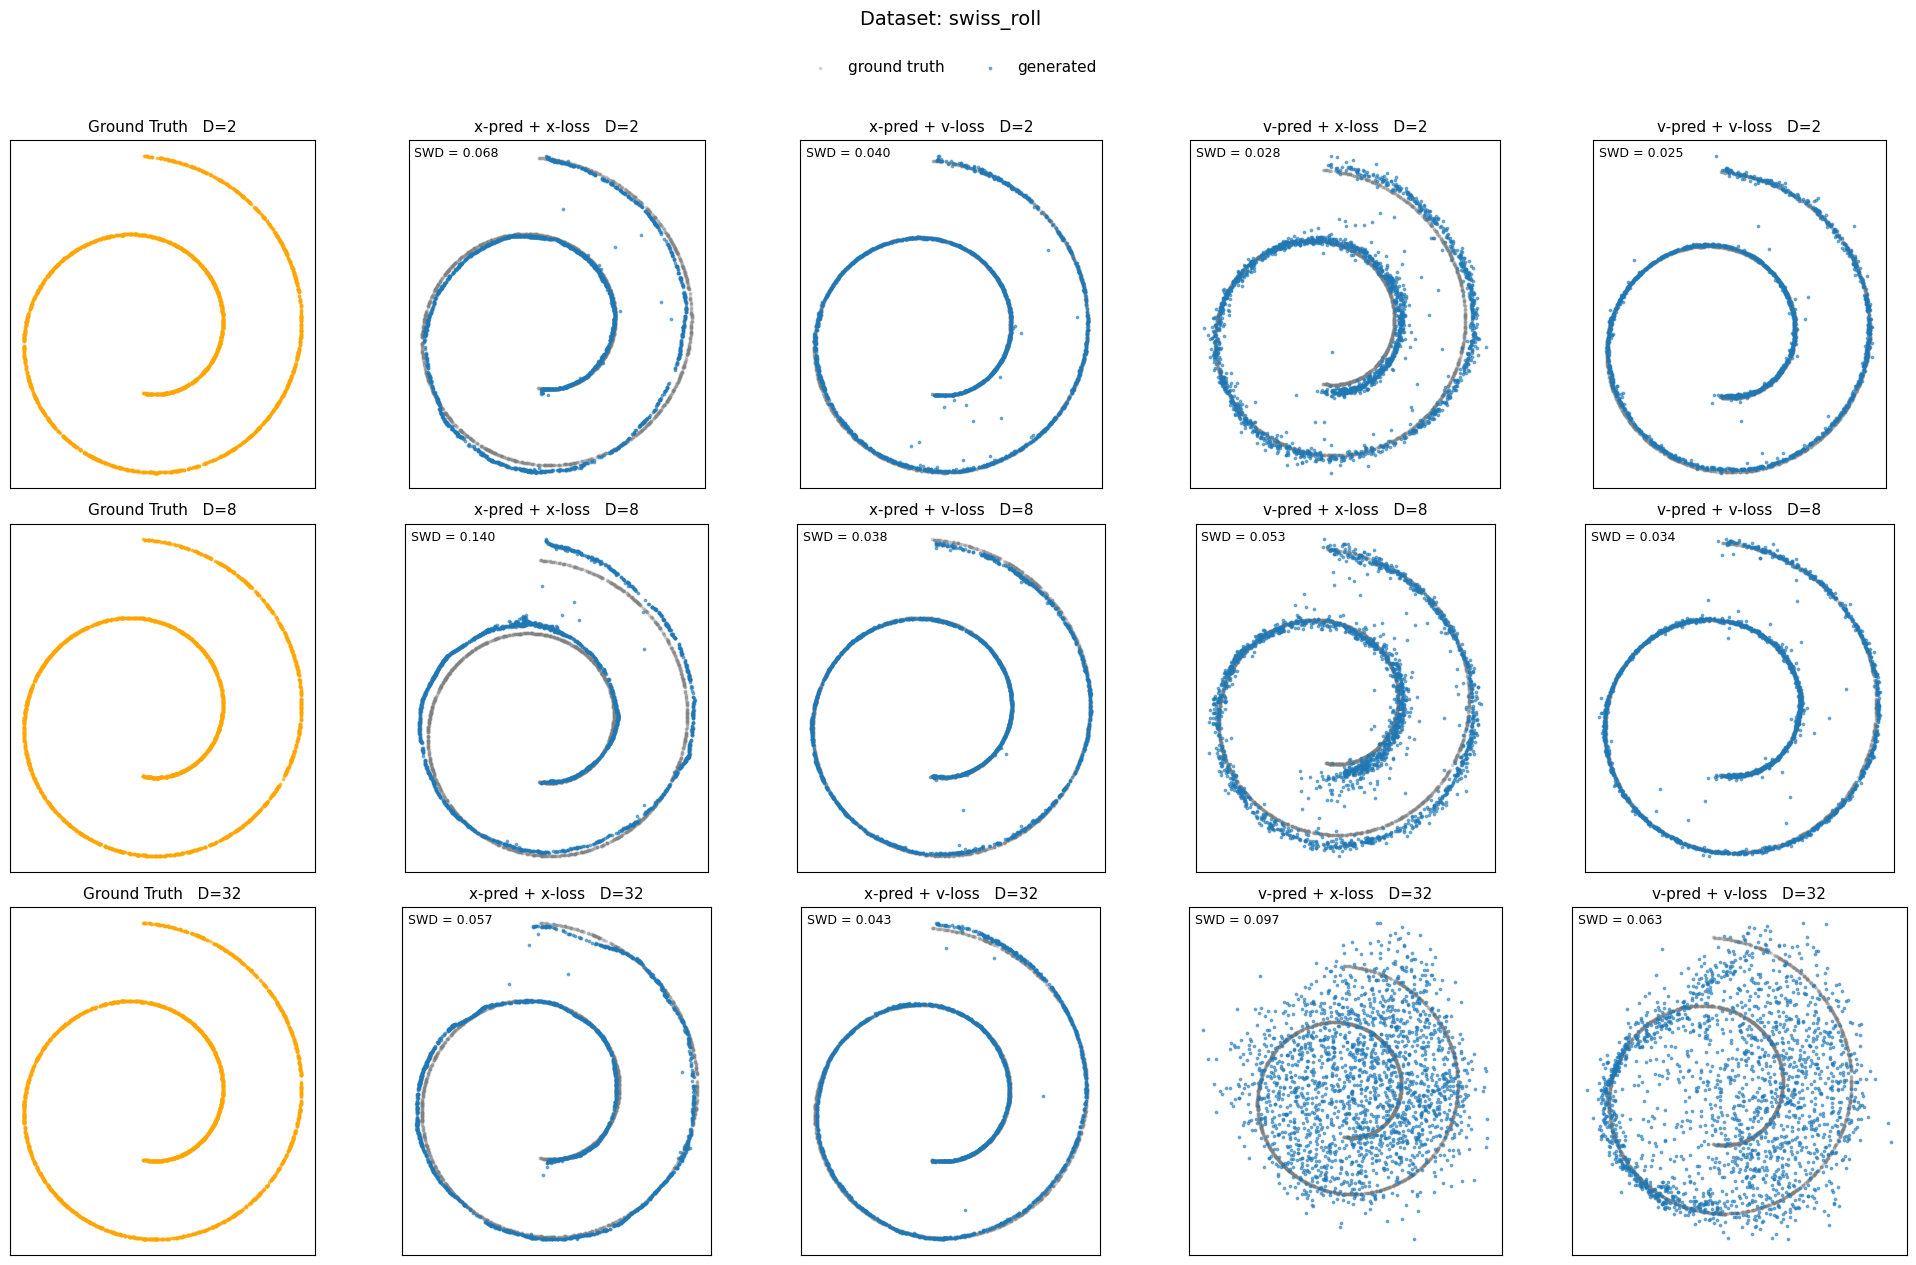

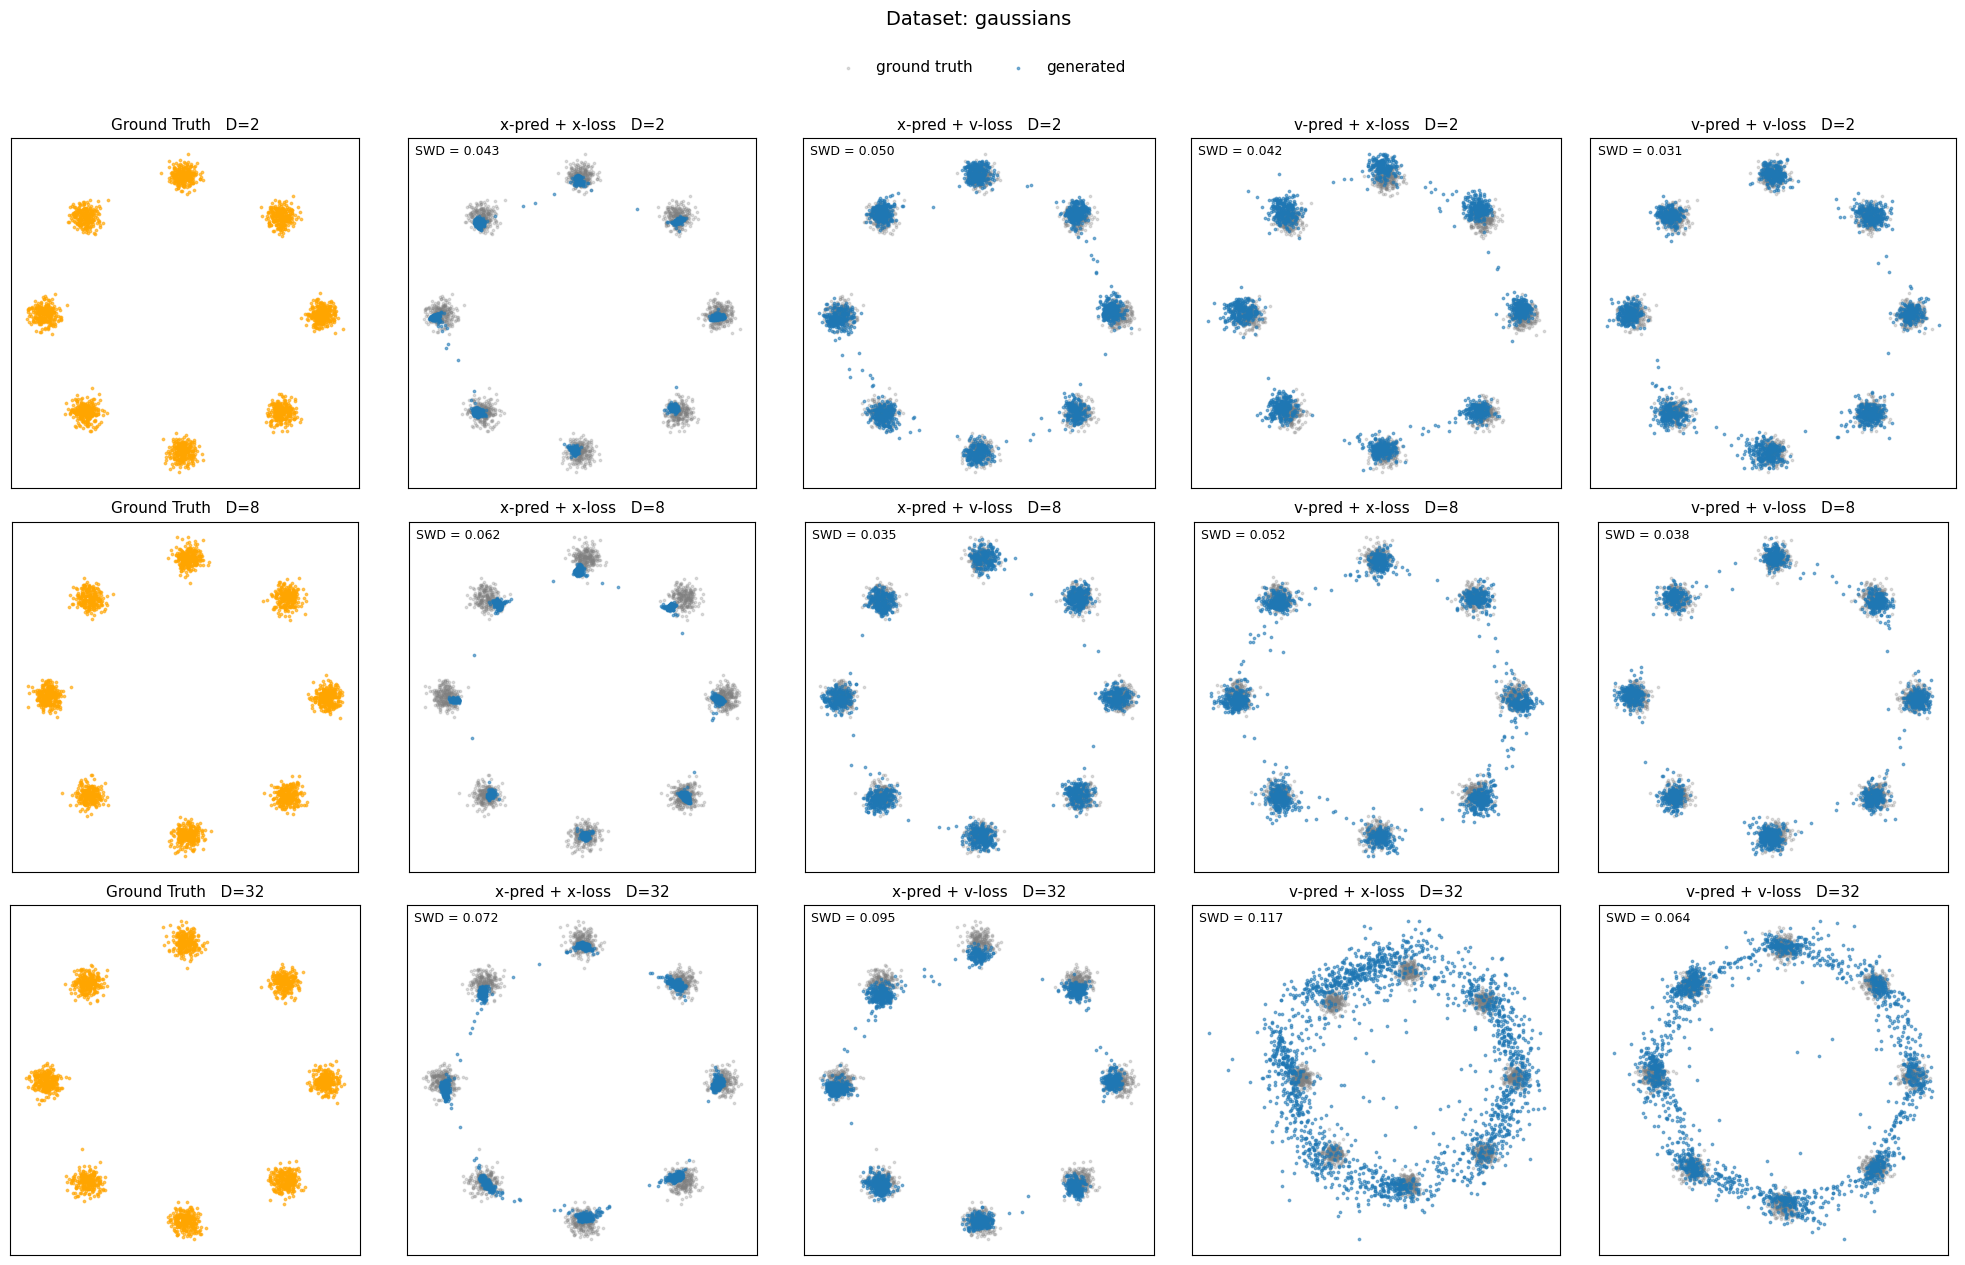

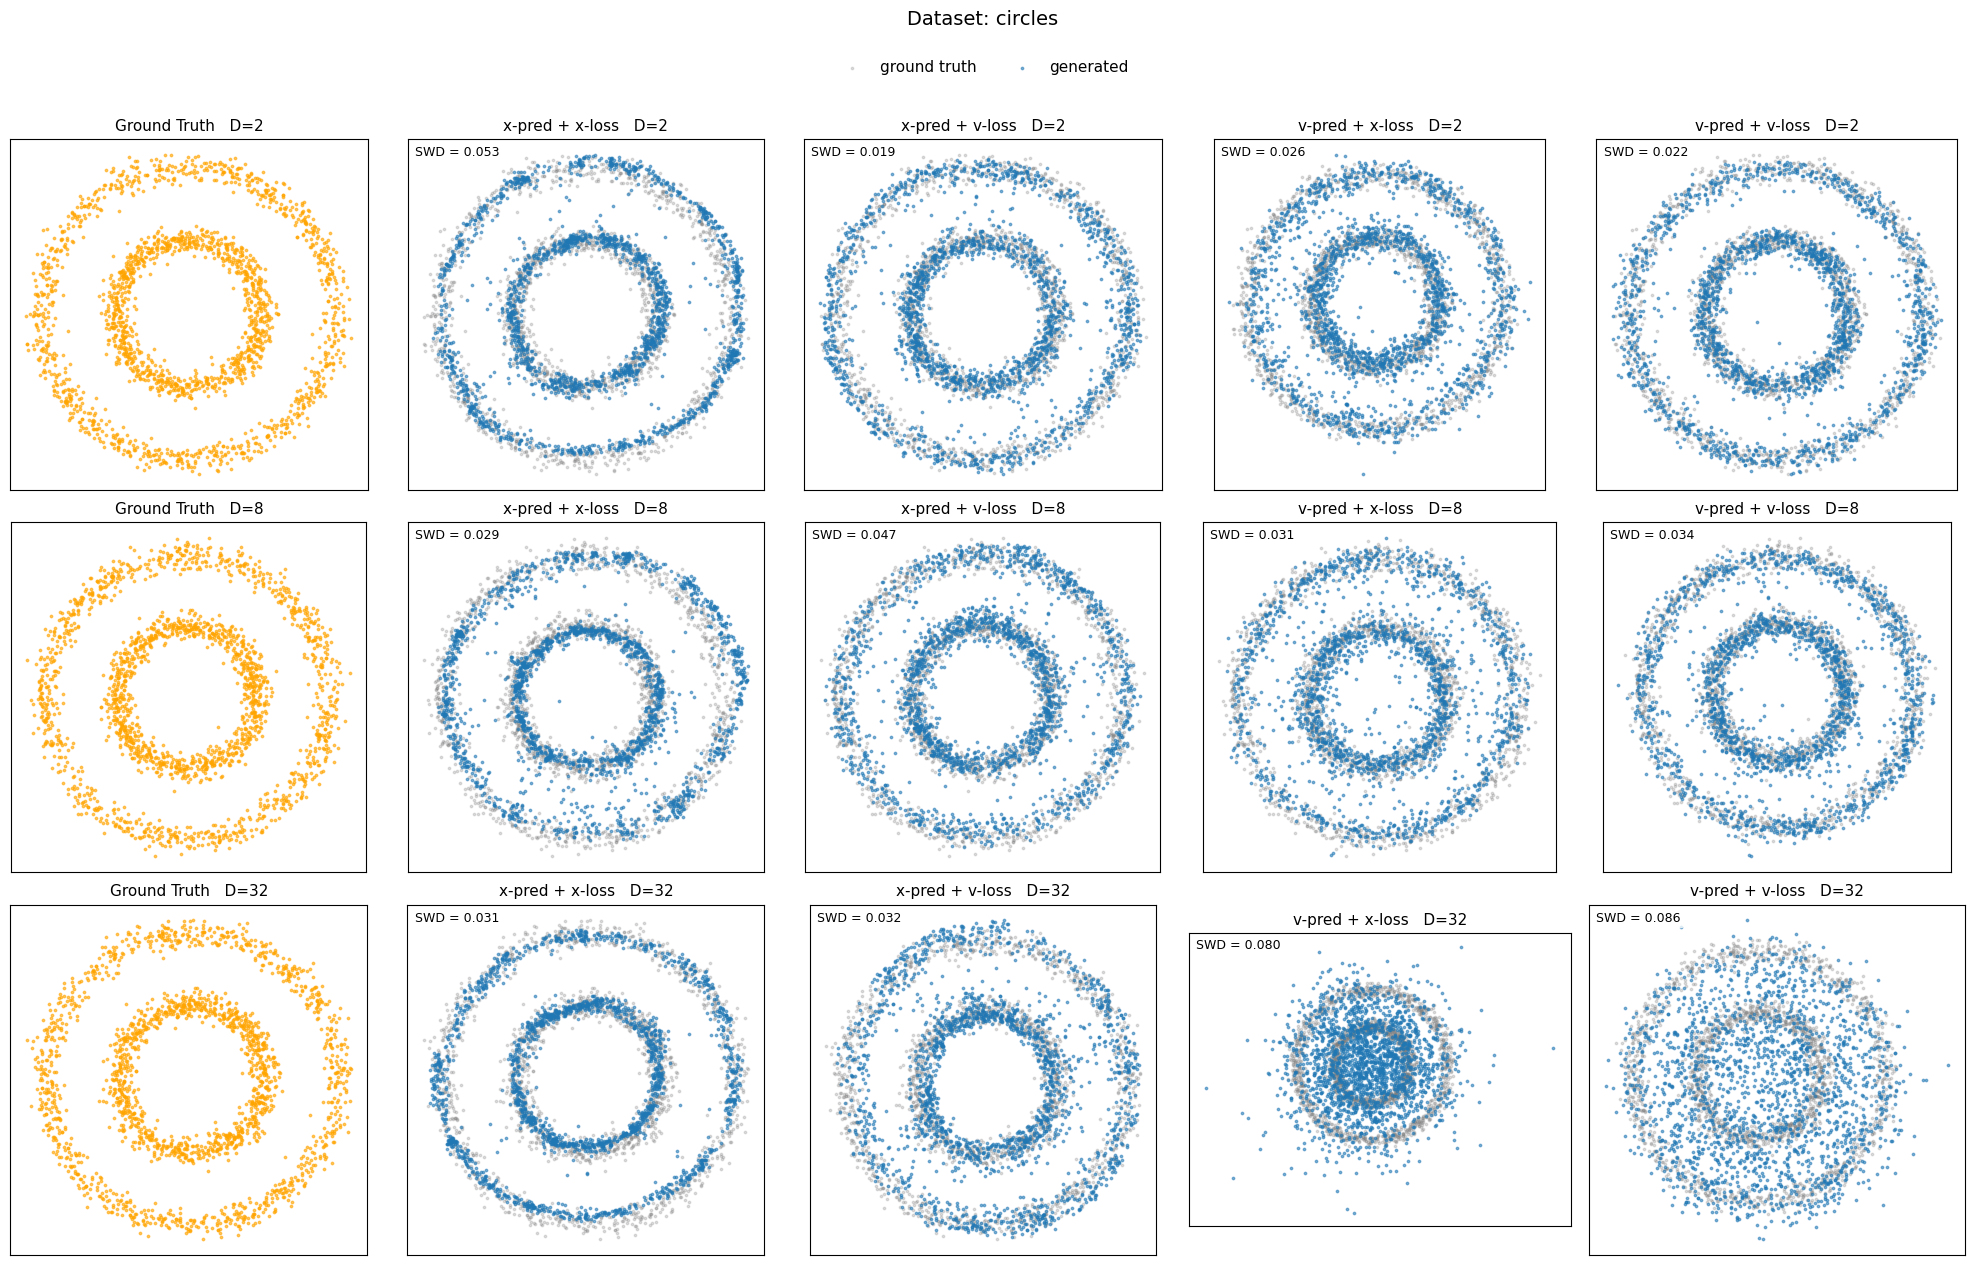

In [ ]:
# === Train all 36 configs ===
device = "cuda" if torch.cuda.is_available() else "cpu"

for dataset in AVAILABLE_DATASETS:
    for D in DIMS:
        for pred, loss in PRED_LOSS:
            tag = model_tag(dataset, D, pred, loss)
            path = MODEL_DIR / f"{tag}.pt"
            if path.exists():
                print(f"[skip] {tag} already trained")
                continue
            print(f"[train] {tag}")
            train_one_config(dataset, D, pred, loss, device, TRAIN_STEPS)

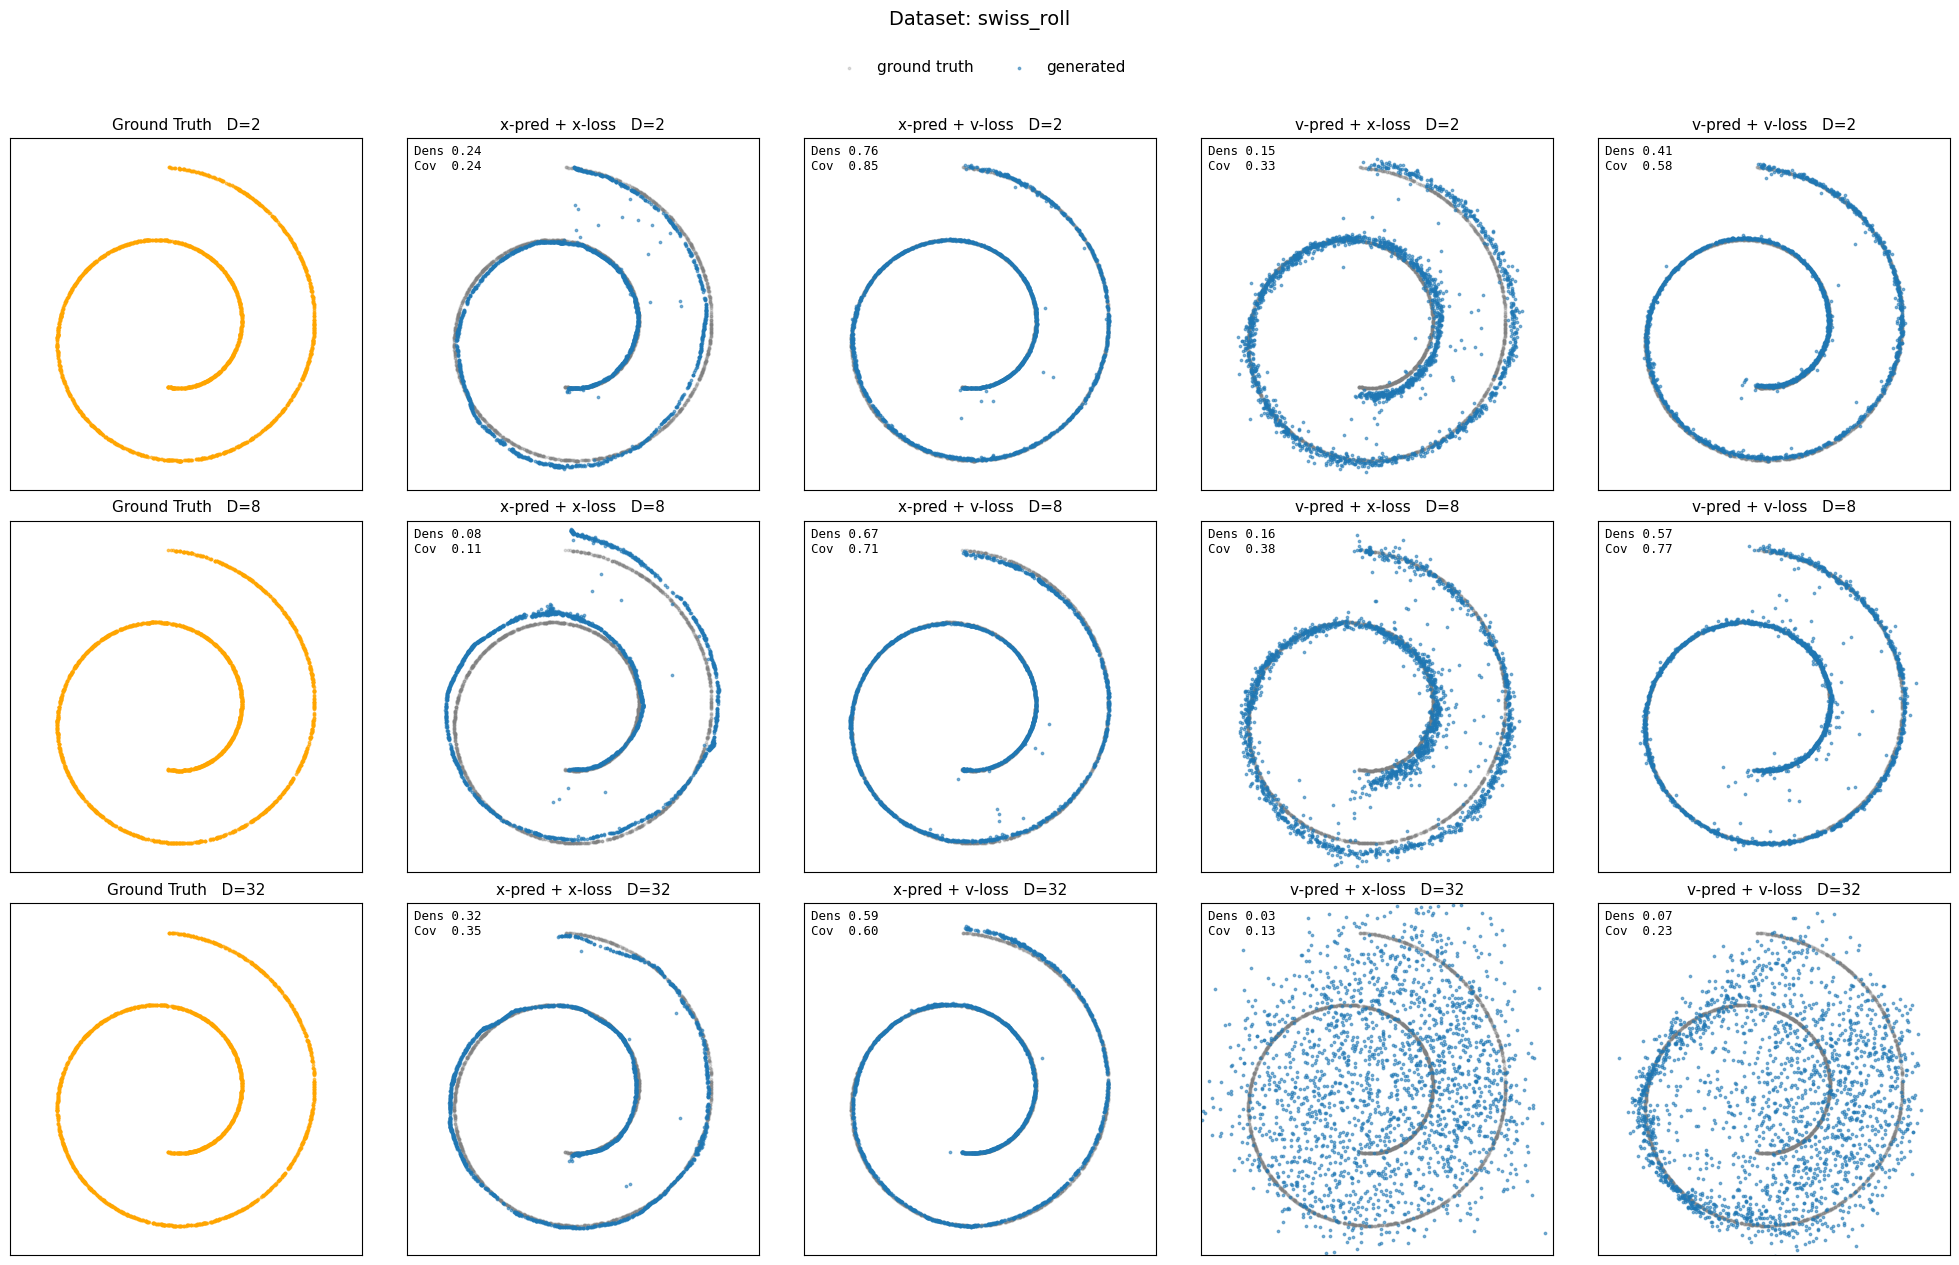

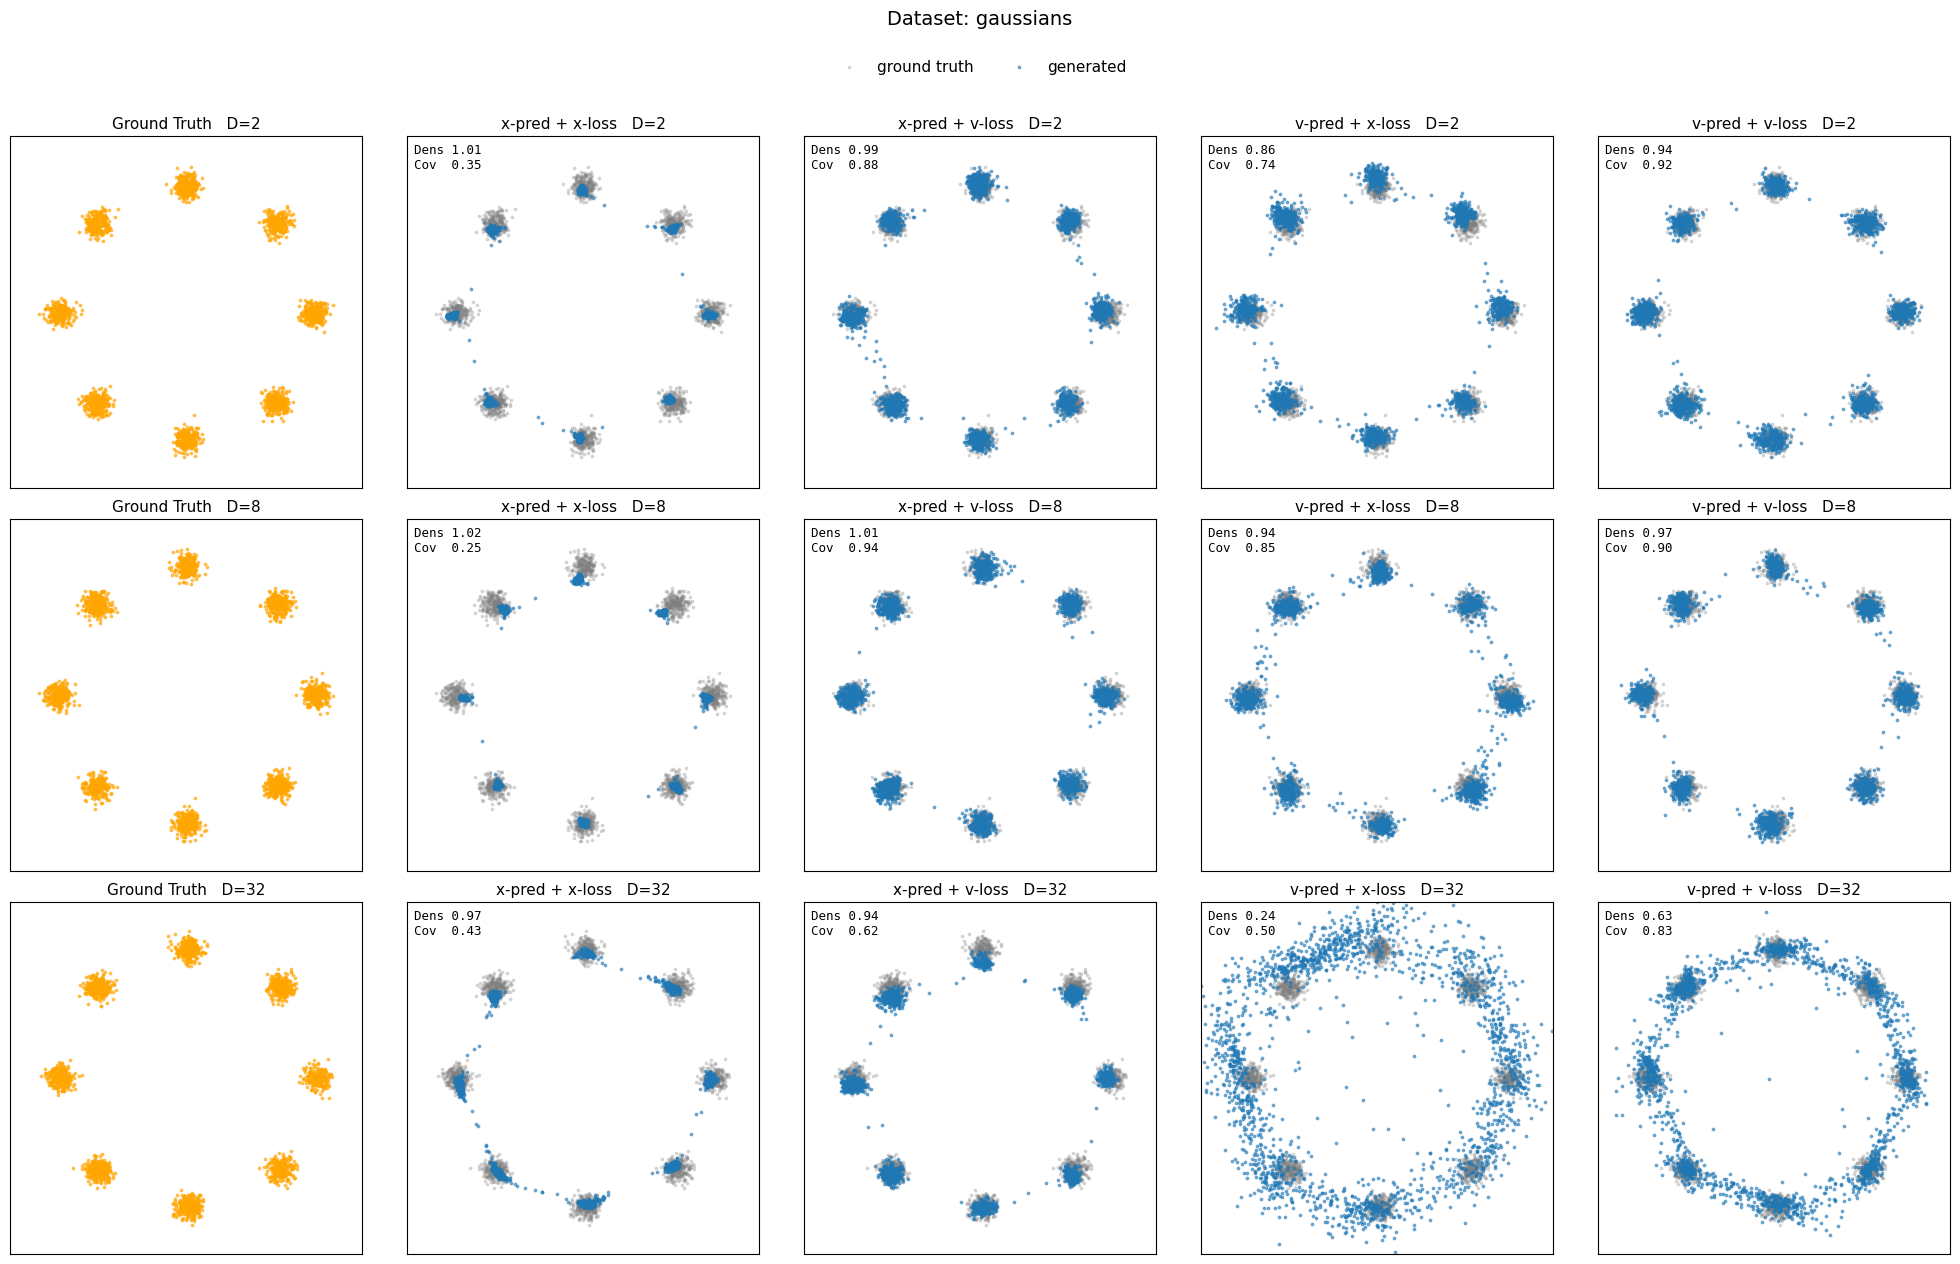

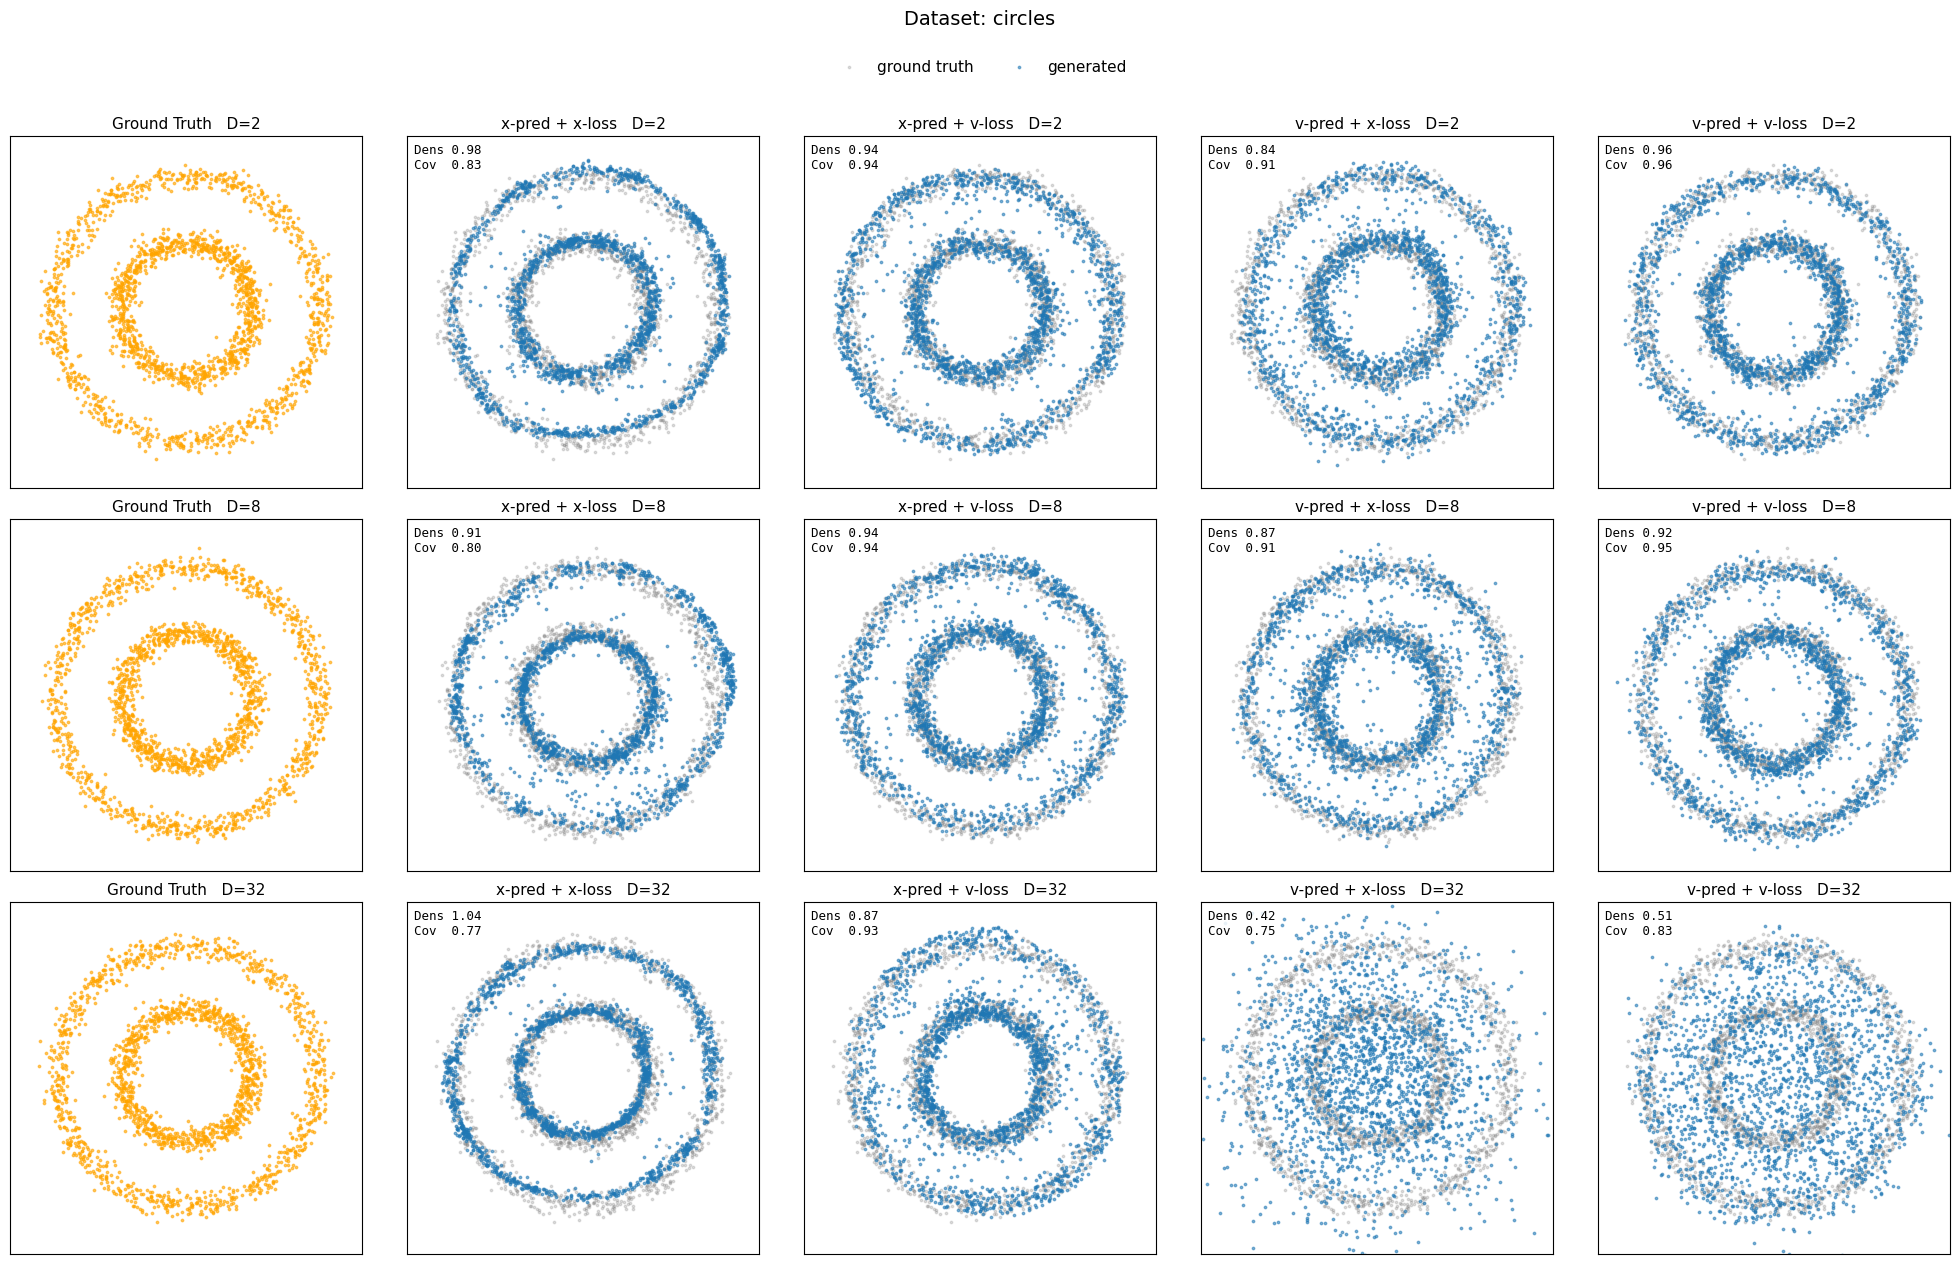

In [11]:
# === Plot one grid per dataset ===
for dataset in AVAILABLE_DATASETS:
    plot_grid(dataset, device)

### Loss Curves

Does loss space affect success/failure? Why does x-pred work at high D when v-pred doesn't?

Loss histories are saved as `.npy` files alongside the model weights.

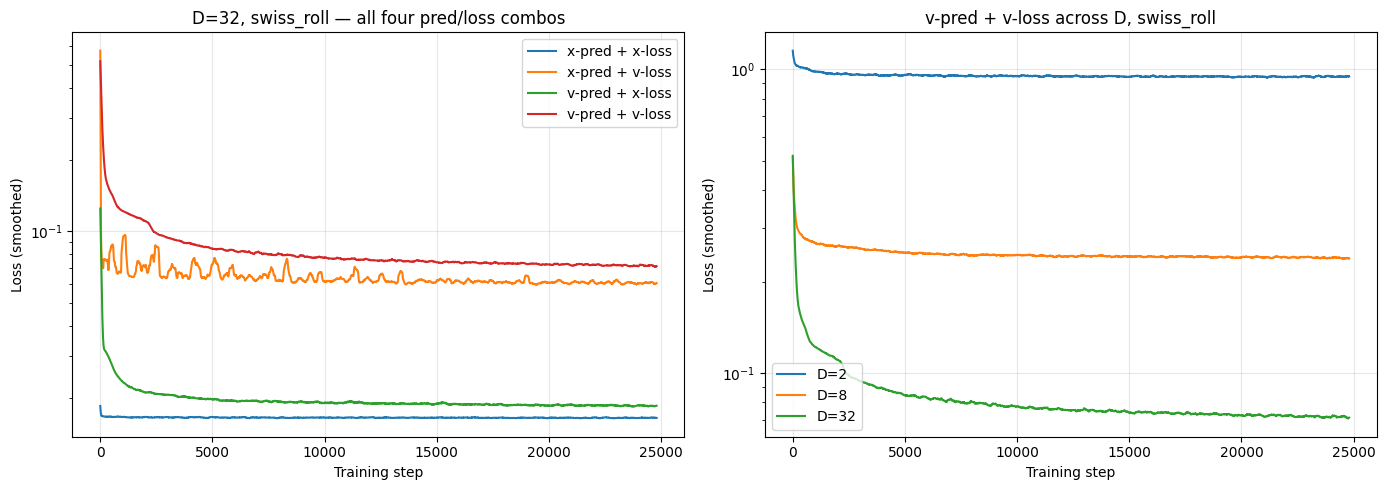

In [12]:
def load_losses(dataset, D, pred, loss):
    path = MODEL_DIR / f"{model_tag(dataset, D, pred, loss)}_losses.npy"
    return np.load(path) if path.exists() else None


def smooth(x, window=200):
    if len(x) < window:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")


LOSS_DATASET = "swiss_roll"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: at D=32, all 4 pred/loss combos. All four train cleanly,
# but only x-pred configs generate well at this D (cf. SWD plot).
ax = axes[0]
plotted = False
for pred, loss in PRED_LOSS:
    losses = load_losses(LOSS_DATASET, 32, pred, loss)
    if losses is None:
        continue
    ax.plot(smooth(losses), label=f"{pred}-pred + {loss}-loss", linewidth=1.5)
    plotted = True

ax.set_xlabel("Training step")
ax.set_ylabel("Loss (smoothed)")
ax.set_yscale("log")
ax.set_title(f"D=32, {LOSS_DATASET} — all four pred/loss combos")
ax.grid(True, alpha=0.3)
if plotted:
    ax.legend()
else:
    ax.text(0.5, 0.5, "no loss data\n(retrain D=32 configs to populate)",
            ha="center", va="center", transform=ax.transAxes, fontsize=11)

# Panel 2: v-pred + v-loss across D ∈ {2, 8, 32}. Loss curves look similar,
# yet generation quality collapses as D grows — evidence that the prediction
# target (not optimisation) is what fails at high D.
ax = axes[1]
plotted = False
for D in DIMS:
    losses = load_losses(LOSS_DATASET, D, "v", "v")
    if losses is None:
        continue
    ax.plot(smooth(losses), label=f"D={D}", linewidth=1.5)
    plotted = True

ax.set_xlabel("Training step")
ax.set_ylabel("Loss (smoothed)")
ax.set_yscale("log")
ax.set_title(f"v-pred + v-loss across D, {LOSS_DATASET}")
ax.grid(True, alpha=0.3)
if plotted:
    ax.legend()
else:
    ax.text(0.5, 0.5, "no loss data\n(retrain v-pred+v-loss configs to populate)",
            ha="center", va="center", transform=ax.transAxes, fontsize=11)

fig.tight_layout()
fig.savefig(FIG_DIR / "loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

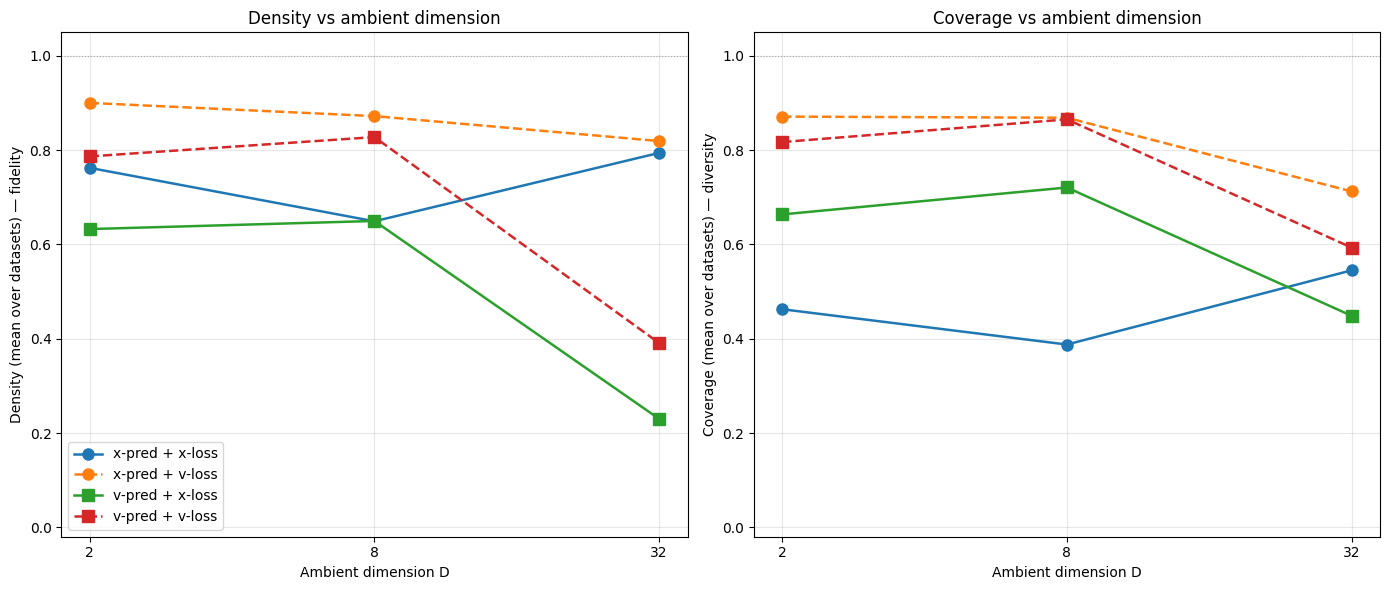

In [13]:
results = []                       # list of (pred, loss, D, dataset, density, coverage)

for dataset in AVAILABLE_DATASETS:
    for D in DIMS:
        for pred, loss in PRED_LOSS:
            tag = model_tag(dataset, D, pred, loss)
            model = JiM(hidden_dim=256, D=D).to(device)
            model.load_state_dict(torch.load(MODEL_DIR / f"{tag}.pt", map_location=device))
            model.eval()

            gen   = generate_samples(model, D, pred, device)
            gt    = get_ground_truth(dataset, D)
            gen2d = project_to_2d(gen, dataset, D)
            gt2d  = project_to_2d(gt, dataset, D)

            dens, cov = density_coverage(gen2d, gt2d)
            results.append((pred, loss, D, dataset, dens, cov))

# Aggregate: mean Density / Coverage across datasets, per (pred, loss, D)
agg = {}                           # {(pred, loss): {D: (mean_dens, mean_cov)}}
for pred, loss, D, _ds, dens, cov in results:
    agg.setdefault((pred, loss), {}).setdefault(D, []).append((dens, cov))
agg = {
    k: {D: (float(np.mean([v[0] for v in vs])), float(np.mean([v[1] for v in vs])))
        for D, vs in d.items()}
    for k, d in agg.items()
}

# Two-panel plot: Density (fidelity) and Coverage (diversity) vs ambient D.
fig, (ax_d, ax_c) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
markers    = {"x": "o", "v": "s"}
linestyles = {"x": "-", "v": "--"}

for (pred, loss), d_to_metrics in agg.items():
    Ds = sorted(d_to_metrics.keys())
    densities = [d_to_metrics[D][0] for D in Ds]
    coverages = [d_to_metrics[D][1] for D in Ds]
    style = dict(marker=markers[pred], linestyle=linestyles[loss],
                 label=f"{pred}-pred + {loss}-loss",
                 linewidth=1.8, markersize=8)
    ax_d.plot(Ds, densities, **style)
    ax_c.plot(Ds, coverages, **style)

for ax, title, ylabel in [
    (ax_d, "Density vs ambient dimension",  "Density (mean over datasets) — fidelity"),
    (ax_c, "Coverage vs ambient dimension", "Coverage (mean over datasets) — diversity"),
]:
    ax.set_xscale("log", base=2)
    ax.set_xticks(DIMS); ax.set_xticklabels(DIMS)
    ax.set_xlabel("Ambient dimension D")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(-0.02, 1.05)       # both metrics are ~[0, 1]; clip the rare Density > 1.
    ax.grid(True, which="both", alpha=0.3)
    ax.axhline(1.0, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)

ax_d.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "density_coverage_vs_dimension.png", dpi=150, bbox_inches="tight")
plt.show()